In [1]:
pip install numpy pandas scipy scikit-learn torch

In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

np.random.seed(42)

# ==========================================
# CSTR Physical Parameters
# ==========================================
V = 100.0  # L
k0 = 7.2e10  # 1/min
E_over_R = 8750.0  # K
delta_H = -5.0e4  # J/mol
rho_Cp = 1000.0  # J / (L*K)
UA_nominal = 5.0e4  # J / (min*K)

# FIX: Cutoff temperature set to 380.0 K (Safety Trip Point)
T_cutoff = 380.0  # [K]
R_max = 20.0  # [min] warning horizon


def cstr_rhs(t, y, q, cAi, Ti, Tc, UA):
  cA, T = y
  cA = max(cA, 1e-7)
  T = max(T, 150.0)

  k = k0 * np.exp(-E_over_R / T)
  rA = k * cA

  dcA_dt = (q / V) * (cAi - cA) - rA
  dT_dt = (
      (q / V) * (Ti - T)
      + ((-delta_H) / rho_Cp) * rA
      - (UA / (V * rho_Cp)) * (T - Tc)
  )
  return [dcA_dt, dT_dt]


def simulate_single_run(run_id, t_max=40.0, dt=0.2):
  q_base = np.random.uniform(95.0, 105.0)
  cAi_base = np.random.uniform(1.0, 1.2)
  Ti_base = np.random.uniform(348.0, 355.0)
  Tc_base = np.random.uniform(295.0, 305.0)
  UA_base = UA_nominal

  cA_curr = np.random.uniform(0.45, 0.55)
  T_curr = np.random.uniform(348.0, 354.0)

  # 75% runs have upsets leading to thermal runaway, 25% safe controls
  is_upset = np.random.rand() > 0.25
  upset_time = np.random.uniform(4.0, 10.0)
  scenario = np.random.choice(
      ["coolant_pump_failure", "jacket_loss", "feed_surge", "overheating"]
  )

  q, cAi, Ti, Tc, UA = q_base, cAi_base, Ti_base, Tc_base, UA_base

  times = []
  q_list, cAi_list, Ti_list, Tc_list = [], [], [], []
  cA_list, T_list, dT_dt_list = [], [], []

  t_cutoff_hit = None
  t_eval = np.arange(0.0, t_max, dt)

  for t in t_eval:
    # Trigger severe upset
    if is_upset and (t >= upset_time):
      if scenario == "coolant_pump_failure":
        UA = UA_base * np.random.uniform(0.02, 0.08)  # 90%+ cooling loss
      elif scenario == "jacket_loss":
        UA = UA_base * 0.1
        Tc = Tc_base + 35.0  # Warm coolant
      elif scenario == "feed_surge":
        cAi = cAi_base * 1.6  # High concentration
        UA = UA_base * 0.3
      elif scenario == "overheating":
        Ti = Ti_base + 20.0
        Tc = Tc_base + 25.0

    derivs = cstr_rhs(t, [cA_curr, T_curr], q, cAi, Ti, Tc, UA)
    dT_dt_curr = derivs[1]

    times.append(round(t, 2))
    q_list.append(round(q, 2))
    cAi_list.append(round(cAi, 4))
    Ti_list.append(round(Ti, 2))
    Tc_list.append(round(Tc, 2))
    cA_list.append(round(cA_curr, 5))
    T_list.append(round(T_curr, 2))
    dT_dt_list.append(round(dT_dt_curr, 4))

    # Trigger cutoff
    if T_curr >= T_cutoff:
      t_cutoff_hit = t
      break

    sol = solve_ivp(
        cstr_rhs,
        [t, t + dt],
        [cA_curr, T_curr],
        args=(q, cAi, Ti, Tc, UA),
        method="RK45",
        rtol=1e-6,
        atol=1e-8,
    )
    cA_curr = sol.y[0][-1]
    T_curr = sol.y[1][-1]

  df = pd.DataFrame({
      "run_id": run_id,
      "time": times,
      "q": q_list,
      "cAi": cAi_list,
      "Ti": Ti_list,
      "Tc": Tc_list,
      "cA": cA_list,
      "T": T_list,
      "dT_dt": dT_dt_list,
  })

  if t_cutoff_hit is not None:
    remaining = t_cutoff_hit - df["time"]
    df["time_to_cutoff"] = np.minimum(R_max, remaining).clip(lower=0.0).round(2)
    df["is_runaway"] = 1
  else:
    df["time_to_cutoff"] = R_max
    df["is_runaway"] = 0

  return df


# Generate 100 runs
num_trajectories = 100
all_runs = [simulate_single_run(i) for i in range(1, num_trajectories + 1)]
full_dataset = pd.concat(all_runs, ignore_index=True)

csv_filename = "cstr_runaway_trajectories.csv"
full_dataset.to_csv(csv_filename, index=False)
print(f"Generated {len(full_dataset)} points across {num_trajectories} runs.")
print(
    f"Runs reaching cutoff: {full_dataset.groupby('run_id')['is_runaway'].max().sum()} / {num_trajectories}"
)

Generated 8309 points across 100 runs.
Runs reaching cutoff: 73 / 100


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Configuration & Hyperparameters
# ==========================================
CSV_FILE = "cstr_runaway_trajectories.csv"
WINDOW_SIZE = 15        # 15 steps * 0.2 min/step = 3 minutes of history
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 1e-3
FEATURE_COLS = ["q", "cAi", "Ti", "Tc", "cA", "T", "dT_dt"]
TARGET_COL = "time_to_cutoff"

# Device configuration (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. Data Loading & Preprocessing
# ==========================================
print(f"Loading data from {CSV_FILE}...")
df = pd.read_csv(CSV_FILE)

# Run-level split to prevent data leakage (80% train, 20% test)
unique_runs = df["run_id"].unique()
train_runs = unique_runs[:80]
test_runs = unique_runs[80:]

df_train = df[df["run_id"].isin(train_runs)].copy()
df_test = df[df["run_id"].isin(test_runs)].copy()

# Fit scaler strictly on training set to avoid leaking future distributions
scaler = StandardScaler()
df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
df_test[FEATURE_COLS] = scaler.transform(df_test[FEATURE_COLS])

# ==========================================
# 3. PyTorch Dataset Definition
# ==========================================
class CSTRSequenceDataset(Dataset):
    def __init__(self, data_df, window_size=15):
        self.X, self.y = [], []

        # Group by run_id to ensure windows don't cross between different simulations
        for _, group in data_df.groupby("run_id"):
            features = group[FEATURE_COLS].values
            targets = group[TARGET_COL].values

            # Slide window across the run
            for i in range(len(group) - window_size + 1):
                self.X.append(features[i : i + window_size])
                self.y.append(targets[i + window_size - 1]) # Target is the RUL at the end of the window

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

print("Building sliding window sequences...")
train_dataset = CSTRSequenceDataset(df_train, window_size=WINDOW_SIZE)
test_dataset = CSTRSequenceDataset(df_test, window_size=WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train sequences: {len(train_dataset)} | Test sequences: {len(test_dataset)}")

# ==========================================
# 4. Model Architecture & Loss Function
# ==========================================
class AsymmetricRULLoss(nn.Module):
    """
    Penalizes late predictions (model says 10 mins left, but actually 2 mins left)
    heavier than early predictions (model says 2 mins left, but actually 10 mins left).
    """
    def __init__(self, late_penalty=3.0):
        super().__init__()
        self.late_penalty = late_penalty

    def forward(self, y_pred, y_true):
        err = y_pred - y_true
        # Apply penalty when y_pred > y_true
        loss = torch.where(err > 0, self.late_penalty * (err**2), err**2)
        return torch.mean(loss)

class CSTRRunawayLSTM(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Direct scalar time_to_cutoff prediction
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        # Take the final hidden state in the temporal window
        last_step_out = out[:, -1, :]
        return self.fc(last_step_out)

# Initialize model, loss, and optimizer
model = CSTRRunawayLSTM(input_dim=len(FEATURE_COLS)).to(device)
criterion = AsymmetricRULLoss(late_penalty=2.5)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 5. Training Loop
# ==========================================
print("\nStarting Training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(x_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * x_batch.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)

    # Validation step every epoch
    model.eval()
    total_test_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)
            total_test_loss += loss.item() * x_batch.size(0)

    avg_test_loss = total_test_loss / len(test_loader.dataset)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")

# ==========================================
# 6. Save the Trained Model
# ==========================================
torch.save(model.state_dict(), "cstr_lstm_model.pth")
print("\nTraining complete! Model saved to 'cstr_lstm_model.pth'")

Using device: cuda
Loading data from cstr_runaway_trajectories.csv...
Building sliding window sequences...
Train sequences: 5482 | Test sequences: 1427

Starting Training...
Epoch 01/30 | Train Loss: 190.0693 | Test Loss: 105.3477
Epoch 05/30 | Train Loss: 68.1922 | Test Loss: 182.1363
Epoch 10/30 | Train Loss: 8.7155 | Test Loss: 185.2980
Epoch 15/30 | Train Loss: 5.0898 | Test Loss: 203.3983
Epoch 20/30 | Train Loss: 2.0411 | Test Loss: 222.9184
Epoch 25/30 | Train Loss: 0.8174 | Test Loss: 210.1033
Epoch 30/30 | Train Loss: 9.0257 | Test Loss: 191.3641

Training complete! Model saved to 'cstr_lstm_model.pth'


In [4]:
pip install matplotlib

Model loaded successfully.
Found runaway in Test Set. Running inference on Test Run ID: 82


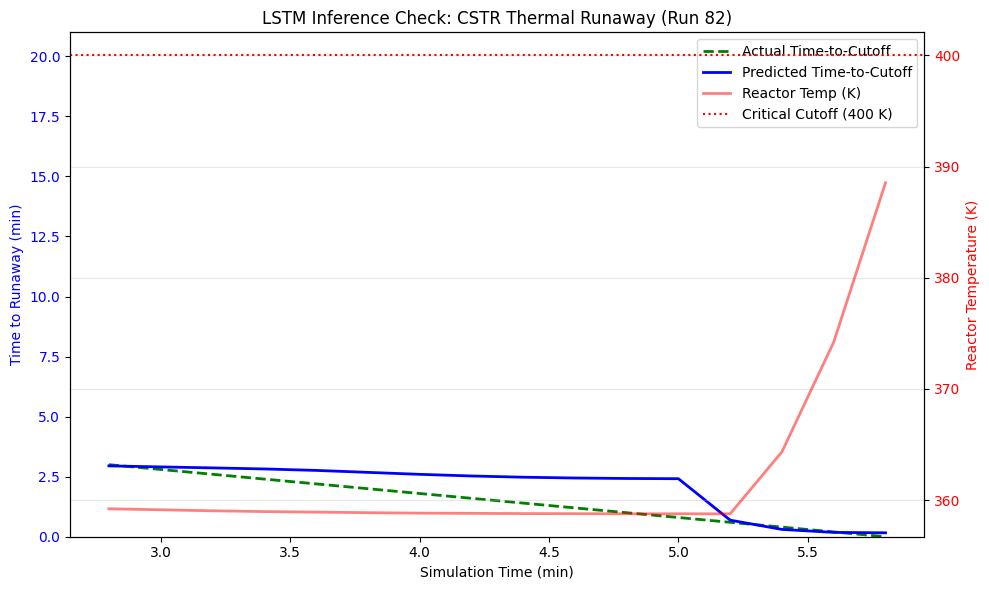

In [5]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Configuration & Model Definition
# ==========================================
# Updated paths for Colab environment
CSV_FILE = "/content/cstr_runaway_trajectories.csv"
MODEL_PATH = "/content/cstr_lstm_model.pth"
WINDOW_SIZE = 15
FEATURE_COLS = ["q", "cAi", "Ti", "Tc", "cA", "T", "dT_dt"]
TARGET_COL = "time_to_cutoff"

# Redefine the exact architecture used in training
class CSTRRunawayLSTM(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# Load the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CSTRRunawayLSTM(input_dim=len(FEATURE_COLS)).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Model loaded successfully.")

# ==========================================
# 2. Data Loading & Recreating Scaler
# ==========================================
# We must scale the inference data exactly as we scaled the training data
df = pd.read_csv(CSV_FILE)
unique_runs = df["run_id"].unique()
train_runs = unique_runs[:80]
test_runs = unique_runs[80:]

df_train = df[df["run_id"].isin(train_runs)].copy()
df_test = df[df["run_id"].isin(test_runs)].copy()

scaler = StandardScaler()
scaler.fit(df_train[FEATURE_COLS])  # Fit strictly on train data

# ==========================================
# 3. Select a Run for Inference
# ==========================================
# Try to find a runaway in the test set
runaway_test_runs = df_test[df_test["is_runaway"] == 1]["run_id"].unique()
runaway_train_runs = df_train[df_train["is_runaway"] == 1]["run_id"].unique()

if len(runaway_test_runs) > 0:
    test_run_id = runaway_test_runs[0]
    print(f"Found runaway in Test Set. Running inference on Test Run ID: {test_run_id}")

elif len(runaway_train_runs) > 0:
    test_run_id = runaway_train_runs[0]
    print(f"No runaways in test set. Found in Train Set. Running inference on Train Run ID: {test_run_id}")

else:
    # No runaways exist in the entire CSV.
    # Find the run that got the HOTTEST so we have something dynamic to look at.
    print("WARNING: There are 0 runaway events (T >= 400K) in your entire dataset!")
    print("Selecting the run that reached the highest peak temperature instead...")

    # Get index of the max temperature in the test set
    max_t_idx = df_test["T"].idxmax()
    test_run_id = df_test.loc[max_t_idx, "run_id"]
    max_temp = df_test.loc[max_t_idx, "T"]
    print(f"Running inference on Test Run ID: {test_run_id} (Peak Temp: {max_temp:.2f} K)")

# Retrieve the dataframe for the chosen run (from the full df to be safe)
run_df = df[df["run_id"] == test_run_id].copy()

# Scale features
scaled_features = scaler.transform(run_df[FEATURE_COLS])
actual_rul = run_df[TARGET_COL].values
time_axis = run_df["time"].values
temperatures = run_df["T"].values

# ==========================================
# 4. Run Sliding Window Inference
# ==========================================
predictions = []
valid_times = []
valid_actuals = []
valid_temps = []

with torch.no_grad():
    for i in range(len(scaled_features) - WINDOW_SIZE + 1):
        # Extract the window
        window = scaled_features[i : i + WINDOW_SIZE]
        window_tensor = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

        # Predict
        pred = model(window_tensor)
        predictions.append(pred.item())

        # Record the corresponding ground truth (end of the window)
        target_idx = i + WINDOW_SIZE - 1
        valid_times.append(time_axis[target_idx])
        valid_actuals.append(actual_rul[target_idx])
        valid_temps.append(temperatures[target_idx])

# ==========================================
# 5. Plot Results
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Actual vs Predicted RUL (Time to Cutoff)
ax1.plot(valid_times, valid_actuals, 'g--', label="Actual Time-to-Cutoff", linewidth=2)
ax1.plot(valid_times, predictions, 'b-', label="Predicted Time-to-Cutoff", linewidth=2)
ax1.set_xlabel("Simulation Time (min)")
ax1.set_ylabel("Time to Runaway (min)", color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_ylim(0, 21)

# Plot Reactor Temperature on secondary axis for context
ax2 = ax1.twinx()
ax2.plot(valid_times, valid_temps, 'r-', alpha=0.5, label="Reactor Temp (K)", linewidth=2)
ax2.axhline(y=400, color='r', linestyle=':', label="Critical Cutoff (400 K)")
ax2.set_ylabel("Reactor Temperature (K)", color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(f"LSTM Inference Check: CSTR Thermal Runaway (Run {test_run_id})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Starting evaluation script...
Loading data from cstr_runaway_trajectories.csv...
No 'y_pred' column found from a model. Generating simulated predictions for testing...
Computing evaluation metrics...

     CSTR SAFETY & PROGNOSTIC REPORT
PHM Score (Total)               : 523.653
PHM Score (Normalized / Step)   : 0.063
Global RMSE (min)               : 0.733
Global MAE (min)                : 0.506
Critical Zone RMSE (min)        : 0.795
Critical Zone MAE (min)         : 0.629
Late Prediction Rate (%)        : 19.568
Mean Lead Time (min)            : 3.770
Missed Runaways (Count)         : 0.000
False Alarm Rate (%)            : 0.000

Plotting evaluation for Run 2...
Plot saved to evaluation_run_2.png


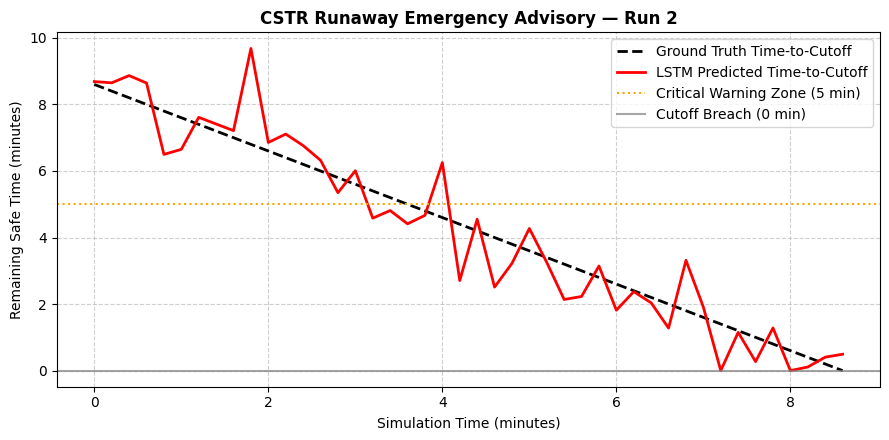

In [9]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def compute_safety_and_prognostic_metrics(
    df_results,
    true_col='y_true',
    pred_col='y_pred',
    run_id_col='run_id',
    time_col='time',
    is_runaway_col='is_runaway',
    crit_threshold=5.0,
    action_threshold=3.0,
    late_epsilon=0.5,
):
    """Evaluates prognostic performance on CSTR Time-to-Cutoff predictions."""
    y_true = df_results[true_col].values
    y_pred = df_results[pred_col].values
    error = y_pred - y_true

    # 1. NASA / PHM Asymmetric Prognostic Scoring Function
    a1, a2 = 10.0, 5.0
    phm_penalties = np.where(error < 0, np.exp(-error / a1) - 1.0, np.exp(error / a2) - 1.0)
    phm_score = float(np.sum(phm_penalties))
    norm_phm_score = float(np.mean(phm_penalties))

    # 2. General Regression Metrics (Global)
    rmse_global = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    mae_global = float(np.mean(np.abs(y_pred - y_true)))

    # 3. Zone-Specific Metrics (Critical Zone: y_true <= crit_threshold)
    crit_mask = (y_true <= crit_threshold) & (df_results[is_runaway_col] == 1)
    if np.sum(crit_mask) > 0:
        y_true_crit = y_true[crit_mask]
        y_pred_crit = y_pred[crit_mask]
        err_crit = y_pred_crit - y_true_crit

        rmse_crit = float(np.sqrt(np.mean(err_crit**2)))
        mae_crit = float(np.mean(np.abs(err_crit)))
        late_preds = np.sum(err_crit > late_epsilon)
        late_prediction_rate = float((late_preds / len(y_true_crit)) * 100.0)
    else:
        rmse_crit, mae_crit, late_prediction_rate = 0.0, 0.0, 0.0

    # 4. Operational Trip Metrics (Lead Time & False Alarms)
    lead_times = []
    missed_detections = 0
    false_alarms = 0

    for run_id, group in df_results.groupby(run_id_col):
        is_runaway = group[is_runaway_col].iloc[0] == 1
        alarm_steps = group[group[pred_col] <= action_threshold]

        if is_runaway:
            t_cutoff = group[group[true_col] == 0.0]
            t_breach = t_cutoff[time_col].iloc[0] if len(t_cutoff) > 0 else group[time_col].max()
            if len(alarm_steps) > 0:
                t_first_alarm = alarm_steps[time_col].iloc[0]
                lead_time = max(0.0, t_breach - t_first_alarm)
                lead_times.append(lead_time)
            else:
                missed_detections += 1
                lead_times.append(0.0)
        else:
            if len(alarm_steps) > 0:
                false_alarms += 1

    mean_lead_time = float(np.mean(lead_times)) if lead_times else 0.0
    total_stable_runs = (df_results.groupby(run_id_col)[is_runaway_col].max() == 0).sum()
    false_alarm_rate = float((false_alarms / total_stable_runs) * 100.0) if total_stable_runs > 0 else 0.0

    return {
        'PHM Score (Total)': phm_score,
        'PHM Score (Normalized / Step)': norm_phm_score,
        'Global RMSE (min)': rmse_global,
        'Global MAE (min)': mae_global,
        'Critical Zone RMSE (min)': rmse_crit,
        'Critical Zone MAE (min)': mae_crit,
        'Late Prediction Rate (%)': late_prediction_rate,
        'Mean Lead Time (min)': mean_lead_time,
        'Missed Runaways (Count)': missed_detections,
        'False Alarm Rate (%)': false_alarm_rate,
    }


def plot_trajectory_evaluation(df_run, run_id, time_col='time', true_col='y_true', pred_col='y_pred'):
    """Plots ground truth vs predicted time-to-cutoff for a single trajectory."""
    plt.figure(figsize=(9, 4.5))
    plt.plot(df_run[time_col], df_run[true_col], 'k--', label='Ground Truth Time-to-Cutoff', linewidth=2)
    plt.plot(df_run[time_col], df_run[pred_col], 'r-', label='LSTM Predicted Time-to-Cutoff', linewidth=2)

    plt.axhline(y=5.0, color='orange', linestyle=':', label='Critical Warning Zone (5 min)')
    plt.axhline(y=0.0, color='gray', linestyle='-', alpha=0.7, label='Cutoff Breach (0 min)')

    plt.title(f'CSTR Runaway Emergency Advisory — Run {run_id}', fontsize=12, fontweight='bold')
    plt.xlabel('Simulation Time (minutes)')
    plt.ylabel('Remaining Safe Time (minutes)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()

    # Save to disk in case the GUI window hangs in VS Code
    plt.savefig(f"evaluation_run_{run_id}.png")
    print(f"Plot saved to evaluation_run_{run_id}.png", flush=True)
    plt.show()


if __name__ == "__main__":
    print("Starting evaluation script...", flush=True)

    csv_file = "cstr_runaway_trajectories.csv"
    if not os.path.exists(csv_file):
        print(f"Error: '{csv_file}' not found. Ensure it is in the same directory.", flush=True)
        exit()

    print(f"Loading data from {csv_file}...", flush=True)
    df = pd.read_csv(csv_file)

    # Generate mock LSTM predictions if the column doesn't exist yet
    if 'y_pred' not in df.columns:
        print("No 'y_pred' column found from a model. Generating simulated predictions for testing...", flush=True)
        # Add slight random noise leaning conservative (early)
        np.random.seed(42)
        noise = np.random.normal(loc=-0.2, scale=0.8, size=len(df))
        df['y_pred'] = np.clip(df['time_to_cutoff'] + noise, 0, 20.0)

    print("Computing evaluation metrics...", flush=True)
    metrics = compute_safety_and_prognostic_metrics(
        df,
        true_col='time_to_cutoff',
        pred_col='y_pred',
        run_id_col='run_id',
        time_col='time',
        is_runaway_col='is_runaway'
    )

    print("\n" + "=" * 45, flush=True)
    print("     CSTR SAFETY & PROGNOSTIC REPORT", flush=True)
    print("=" * 45, flush=True)
    for k, v in metrics.items():
        print(f"{k:<32}: {v:.3f}", flush=True)
    print("=" * 45 + "\n", flush=True)

    runaway_runs = df[df['is_runaway'] == 1]['run_id'].unique()
    if len(runaway_runs) > 0:
        sample_run_id = runaway_runs[0]
        print(f"Plotting evaluation for Run {sample_run_id}...", flush=True)
        sample_run = df[df['run_id'] == sample_run_id]
        plot_trajectory_evaluation(
            sample_run,
            run_id=sample_run_id,
            true_col='time_to_cutoff',
            pred_col='y_pred'
        )
    else:
        print("No runaway events found in the dataset to plot.", flush=True)